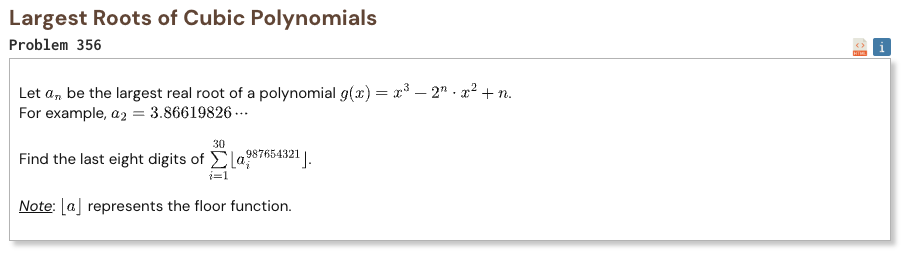

## Initial approach

* avoid computing the largest root directly
* use all three roots together instead
* their power sum is always an integer
* that integer follows a short recurrence
* the two smaller roots contribute less than one in size
* so the wanted floor is the integer power sum minus one
* use matrix exponentiation to jump to the huge exponent quickly

In [1]:
MOD = 10 ** 8
EXPONENT = 987654321

def mat_mul(a, b, mod):
    rows = len(a)
    cols = len(b[0])
    inner = len(b)

    result = [[0] * cols for _ in range(rows)]

    for i in range(rows):
        for k in range(inner):
            for j in range(cols):
                result[i][j] = (result[i][j] + a[i][k] * b[k][j]) % mod

    return result

def mat_pow(matrix, power, mod):
    size = len(matrix)
    result = [[0] * size for _ in range(size)]

    for i in range(size):
        result[i][i] = 1

    while power:
        if power & 1:
            result = mat_mul(result, matrix, mod)

        matrix = mat_mul(matrix, matrix, mod)
        power //= 2

    return result

def root_power_sum(n, power, mod):
    a = pow(2, n, mod)

    if power == 0:
        return 3 % mod

    if power == 1:
        return a

    if power == 2:
        return a * a % mod

    transition = [
        [a, 0, -n % mod],
        [1, 0, 0],
        [0, 1, 0]
    ]

    start = [
        a * a % mod,
        a,
        3
    ]

    matrix = mat_pow(transition, power - 2, mod)

    total = 0

    for i in range(3):
        total = (total + matrix[0][i] * start[i]) % mod

    return total

def solve():
    total = 0

    for n in range(1, 31):
        total = (total + root_power_sum(n, EXPONENT, MOD) - 1) % MOD

    return total

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 28010159
CPU times: user 8.24 ms, sys: 178 μs, total: 8.42 ms
Wall time: 8.34 ms
